# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fmarryam70-ux/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

My lane is Lane 2: Refresh / Content Opportunity Scoring. The decision this
supports: a content reviewer with limited time cannot check every page for
decline — they need a short, trustworthy ranked list of which pages to open
first. This notebook tests whether a simple learned model can rank pages
better than a hand-built rule, while staying explainable enough to trust.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/fmarryam70-ux/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Research question: Which declining page should a reviewer fix first?")
print("Decision supported: prioritizing a content-refresh review queue.")

Research question: Which declining page should a reviewer fix first?
Decision supported: prioritizing a content-refresh review queue.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Dataset: content_refresh_anonymized.csv, an anonymized page-level slice from
FlyRank's search-intelligence warehouse. Grain: one row = one content page,
grouped under a pseudonymous client_id. client_id is used only for grouping
the train/test split, never as a feature. The release has no calendar dates,
so recency is captured only through content_age_days and days_since_last_update.
No client names, domains, or private queries appear anywhere in the data.

In [2]:
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Base rate (declining): {df['is_declining_label'].mean():.3f}")
print(f"Unique clients: {df['client_id'].nunique()}")

date_cols = [c for c in df.columns if "date" in c.lower()]
print(f"Columns containing calendar dates: {date_cols if date_cols else 'none'}")

Rows: 30000
Columns: 45
Base rate (declining): 0.542
Unique clients: 32
Columns containing calendar dates: ['days_since_last_update']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Baseline (Week 4 rule): a page is flagged stale_visible_page if stale
(180+ days since update) and visible (>=500 impressions/90d), or
low_ctr_visible_page if it ranks top 20 with CTR under 0.5 and is visible.
Models: Logistic Regression, a depth-4 Decision Tree, and a Random Forest
(300 trees, depth 8) — readable first, add complexity only if it earns its
place. Split: 80/20 client-grouped (GroupShuffleSplit on client_id, seed 42)
so no client appears in both train and test — the same grouping used for
the baseline queue. client_id itself is excluded as a feature; no
future-window or label-derived column is used among the features.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()

print(f"Train rows: {len(train)}, Test rows: {len(test)}")
print(f"Client overlap: {len(set(train['client_id']) & set(test['client_id']))}")

def baseline_score(d):
    visible = (d["impressions_90d"] >= 500).astype(int)
    stale = (d["days_since_last_update"] >= 180).astype(int)
    low_ctr_visible = ((d["avg_position"] > 0) & (d["avg_position"] <= 20)
                        & (d["ctr"] < 0.5) & visible).astype(int)
    return (0.55 * stale * visible * np.log1p(d["impressions_90d"])
            + 0.45 * low_ctr_visible * np.log1p(d["impressions_90d"]))

test["baseline_score"] = baseline_score(test)

MISSING_PRONE = ["word_count", "char_count", "search_volume", "competition", "cpc", "scroll_rate"]
for d in (train, test):
    for col in MISSING_PRONE:
        d[f"has_{col}"] = d[col].notna().astype(int)
        d[col] = d[col].fillna(0)
    d["log_impressions_90d"] = np.log1p(d["impressions_90d"])
    d["log_clicks_90d"] = np.log1p(d["clicks_90d"])

NUMERIC = ["log_impressions_90d", "log_clicks_90d", "days_with_impressions", "days_with_sessions",
           "content_age_days", "days_since_last_update", "ctr", "avg_position", "engagement_rate",
           "scroll_rate", "word_count", "char_count", "search_volume", "competition", "cpc"] + \
          [f"has_{c}" for c in MISSING_PRONE]
CATEGORICAL = ["content_type", "main_intent", "age_tier", "freshness_tier", "impression_tier", "position_tier"]

X_train, y_train = train[NUMERIC + CATEGORICAL], train["is_declining_label"]
X_test, y_test = test[NUMERIC + CATEGORICAL], test["is_declining_label"]

pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

models = {
    "logistic_regression": Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "decision_tree": Pipeline([("pre", pre), ("clf", DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=SEED))]),
    "random_forest": Pipeline([("pre", pre), ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=SEED, n_jobs=-1))]),
}

model_scores = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    model_scores[name] = pipe.predict_proba(X_test)[:, 1]

print("Models trained:", list(models.keys()))

Train rows: 23837, Test rows: 6163
Client overlap: 0
Models trained: ['logistic_regression', 'decision_tree', 'random_forest']


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

All approaches are scored on the identical held-out test split using
precision@20 and precision@50 — the metric a reviewer actually experiences:
of the top K pages sent for review, how many were truly declining?
Logistic Regression wins at both depths.

In [4]:
def precision_at_k(y_true, scores, k):
    frame = pd.DataFrame({"y": y_true, "score": scores})
    top = frame.sort_values("score", ascending=False).head(k)
    return float(top["y"].mean())

rows = []
for name, scores in model_scores.items():
    rows.append({"model": name,
                 "precision_at_20": precision_at_k(y_test, scores, 20),
                 "precision_at_50": precision_at_k(y_test, scores, 50)})

rows.append({"model": "base_rate (random)",
             "precision_at_20": y_test.mean(), "precision_at_50": y_test.mean()})
rows.append({"model": "baseline_rules",
             "precision_at_20": precision_at_k(y_test, test["baseline_score"], 20),
             "precision_at_50": precision_at_k(y_test, test["baseline_score"], 50)})

comparison = pd.DataFrame(rows).sort_values("precision_at_50", ascending=False).reset_index(drop=True)
print(comparison.round(3).to_string(index=False))

best_name = comparison.iloc[0]["model"]
print(f"\nBest model by precision@50: {best_name}")

              model  precision_at_20  precision_at_50
logistic_regression            0.850            0.740
      decision_tree            0.450            0.580
      random_forest            0.550            0.580
 base_rate (random)            0.511            0.511
     baseline_rules            0.400            0.420

Best model by precision@50: logistic_regression


## 5. Limitations

*What this work cannot claim.*

This work is correlational, not causal — no experiment was run. The
is_declining_label itself is inherited from the release's trend_direction
field, not independently re-derived. The anonymized data has no calendar
dates, so seasonality can't be checked directly — the error analysis below
shows this is exactly where the model's mistakes come from. Precision@K is
reported from a single client-grouped split (seed 42), not averaged across
splits, so exact numbers carry sampling variance. This 30,000-row release
is a small sample of a much larger warehouse; results on the full data are
untested here. Claims here are observed and decision-support only.

In [5]:
from sklearn.inspection import permutation_importance

best_pipe = models[best_name]
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                               random_state=SEED, scoring="roc_auc", n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=NUMERIC + CATEGORICAL) \
                .sort_values(ascending=False)
print("Top 8 features by permutation importance (ROC-AUC drop when shuffled):")
print(importances.head(8).round(4))

test_c = test.copy()
test_c["model_score"] = model_scores[best_name]
top50 = test_c.sort_values("model_score", ascending=False).head(50)
wrong = top50[top50["is_declining_label"] == 0]
print(f"\nWrong picks in model's top 50: {len(wrong)} of 50")
print(f"Wrong picks in baseline's top 50: {50 - int(precision_at_k(y_test, test['baseline_score'], 50) * 50)}")

Top 8 features by permutation importance (ROC-AUC drop when shuffled):
log_impressions_90d    0.0765
log_clicks_90d         0.0573
impression_tier        0.0363
days_with_sessions     0.0266
avg_position           0.0244
content_age_days       0.0174
scroll_rate            0.0072
char_count             0.0052
dtype: float64

Wrong picks in model's top 50: 13 of 50
Wrong picks in baseline's top 50: 29


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Route the model's top 20-50 ranked pages to reviewers first — halves
   wasted reviews vs. the rule-only baseline (13 wrong picks vs. 29 in top 50).
2. Treat model + rule agreement (stale_visible_page / low_ctr_visible_page)
   as stronger evidence than either signal alone.
3. Before actioning a top pick, do a 60-second seasonality/promo check —
   the model's clearest errors are high-visibility pages whose trend is
   actually up or stable, not down.
4. Watch log_impressions_90d and log_clicks_90d specifically — they drive
   most of the ranking (ROC-AUC drop 0.077 and 0.057).
5. Re-check precision@K as new data windows arrive — this is a single-split,
   single-snapshot read, not a permanent guarantee.

In [6]:
top5 = test_c.sort_values("model_score", ascending=False).head(5)
print("Example reviewer queue — top 5 pages by model score:")
print(top5[["content_id", "model_score", "is_declining_label"]].to_string(index=False))

Example reviewer queue — top 5 pages by model score:
          content_id  model_score  is_declining_label
content_a928cb66d230     0.962691                   1
content_7be5f150dc65     0.955736                   0
content_5d77d3077984     0.948744                   1
content_8ba781dafa55     0.940106                   1
content_87c007fb5c26     0.935960                   1


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Generates the two charts embedded in the deployed paper: model comparison
(precision@20 / precision@50) and permutation feature importance.

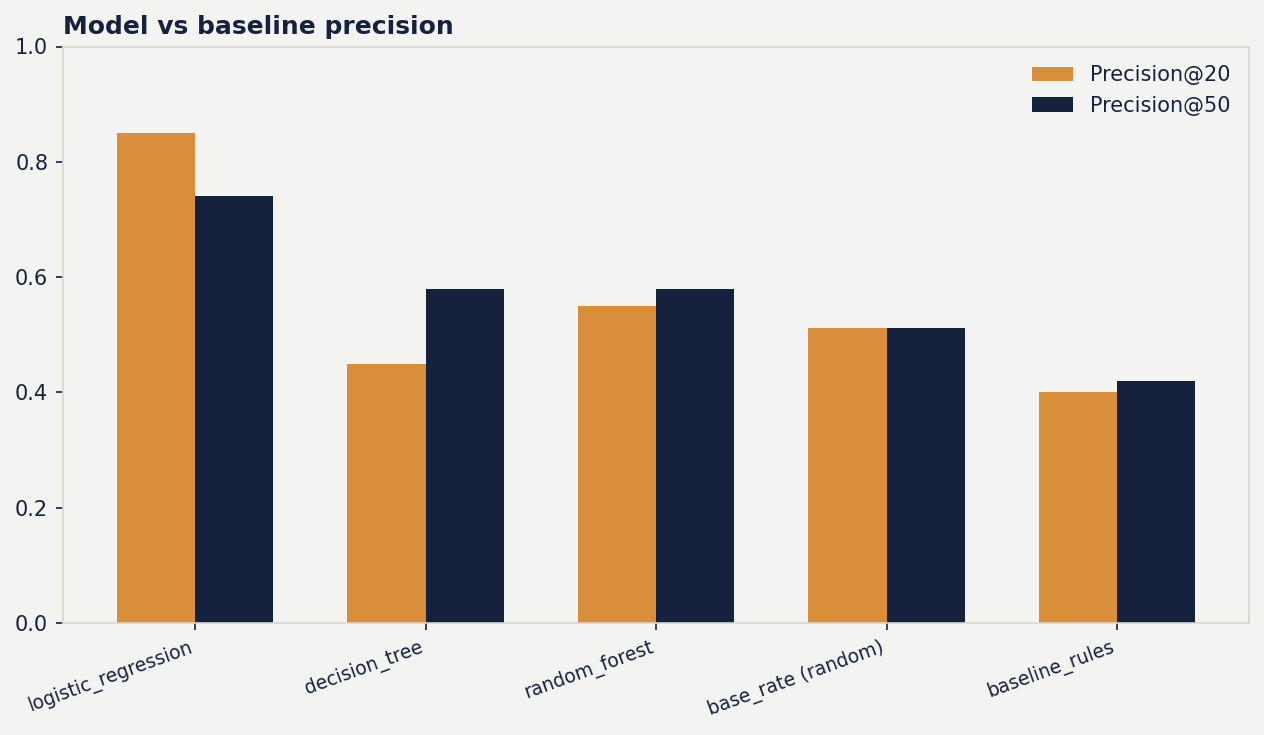

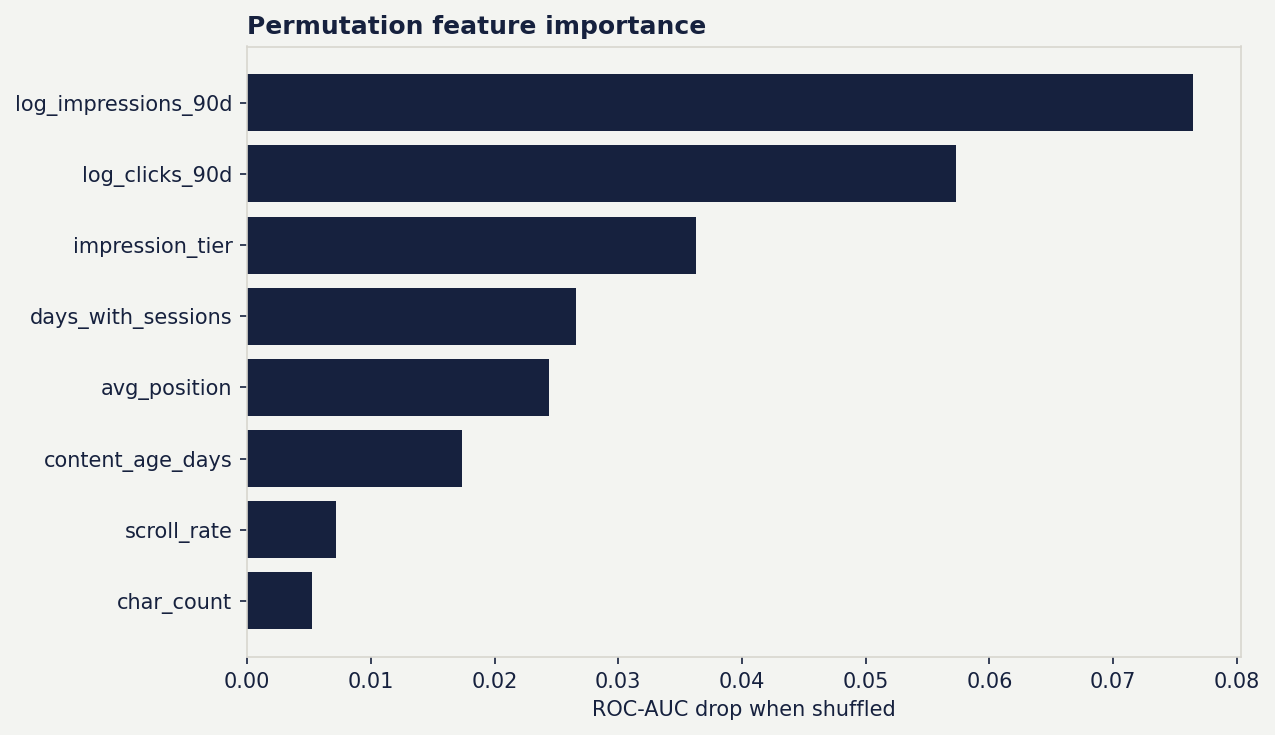

Saved: work/outputs/precision_chart.png, work/outputs/importance_chart.png


In [7]:
import matplotlib.pyplot as plt
import os

INK, PAPER, AMBER, GRID = "#16213E", "#F3F4F1", "#D98E3B", "#D8D6CF"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                      "savefig.facecolor": PAPER, "text.color": INK,
                      "axes.edgecolor": GRID, "axes.labelcolor": INK,
                      "xtick.color": INK, "ytick.color": INK})

os.makedirs("work/outputs", exist_ok=True)

# Chart 1: precision comparison
labels = comparison["model"].tolist()
p20 = comparison["precision_at_20"].tolist()
p50 = comparison["precision_at_50"].tolist()
x = range(len(labels))
fig, ax = plt.subplots(figsize=(8.6, 5.0), dpi=150)
ax.bar([i - 0.17 for i in x], p20, width=0.34, label="Precision@20", color=AMBER)
ax.bar([i + 0.17 for i in x], p50, width=0.34, label="Precision@50", color=INK)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.0); ax.legend(frameon=False)
ax.set_title("Model vs baseline precision", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("work/outputs/precision_chart.png")
plt.show()

# Chart 2: feature importance
top8 = importances.head(8)[::-1]
fig, ax = plt.subplots(figsize=(8.6, 5.0), dpi=150)
ax.barh(top8.index, top8.values, color=INK)
ax.set_xlabel("ROC-AUC drop when shuffled")
ax.set_title("Permutation feature importance", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("work/outputs/importance_chart.png")
plt.show()

print("Saved: work/outputs/precision_chart.png, work/outputs/importance_chart.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.